# Potato Disease Classification

Dataset credits: https://www.kaggle.com/arjuntejaswi/plant-village

### Import all the Dependencies

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML
import numpy as np
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

### Set all the Constants

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 10          # upper bound - EarlyStopping will typically stop sooner
EARLY_STOP_PATIENCE = 6

### Import data into tensorflow dataset object

We will use image_dataset_from_directory api to load all images in tensorflow dataset: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage1",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.


In [4]:
class_names = dataset.class_names
class_names

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [5]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[14  9 14  6  3  0  7  6  3 11  9  8  5  3  3  5  5  9 10  6 14 14  2  2
 14  6  5  2  9 12  2  8]


As you can see above, each element in the dataset is a tuple. First element is a batch of 32 elements of images. Second element is a batch of 32 elements of class labels 

### Visualize some of the images from our dataset

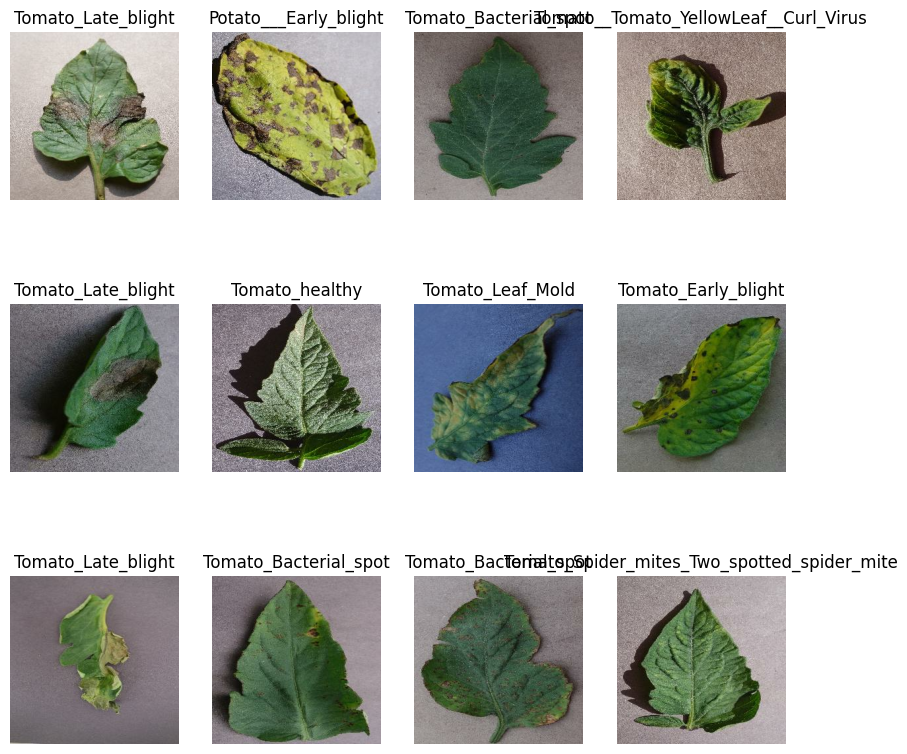

In [6]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

### Function to Split Dataset

Dataset should be bifurcated into 3 subsets, namely:
1. Training: Dataset to be used while training
2. Validation: Dataset to be tested against while training
3. Test: Dataset to be tested against after we trained a model

In [7]:
len(dataset)

645

In [8]:
train_size = 0.8
len(dataset)*train_size

516.0

In [9]:
train_ds = dataset.take(54)
len(train_ds)

54

In [10]:
test_ds = dataset.skip(54)
len(test_ds)

591

In [11]:
val_size=0.1
len(dataset)*val_size

64.5

In [12]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [13]:
test_ds = test_ds.skip(6)
len(test_ds)

585

In [14]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds)

516

In [17]:
len(val_ds)

64

In [18]:
len(test_ds)

65

### Cache, Shuffle, and Prefetch the Dataset

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### Computing Class Weights (to give Recall a boost on minority classes)

This dataset isn't perfectly balanced across all 15 classes (e.g. some Tomato diseases have far more images than some Potato/Pepper classes). When classes are imbalanced, a model can get high accuracy while still missing (i.e. failing to recall) the rarer classes, because misclassifying them barely dents the overall accuracy number.

`class_weight='balanced'` makes the loss function penalize mistakes on under-represented classes more heavily, which pushes the optimizer to catch more true positives (higher recall) for those classes — at a small, usually acceptable, cost in precision.

In [20]:
train_labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))
class_weights

{0: np.float64(1.3391727493917276),
 1: np.float64(0.93446519524618),
 2: np.float64(1.376),
 3: np.float64(1.3916561314791402),
 4: np.float64(9.097520661157025),
 5: np.float64(0.6479105356091819),
 6: np.float64(1.374282147315855),
 7: np.float64(0.7218360655737704),
 8: np.float64(1.4835579514824797),
 9: np.float64(0.7644444444444445),
 10: np.float64(0.819047619047619),
 11: np.float64(0.9917117117117117),
 12: np.float64(0.42732919254658386),
 13: np.float64(3.756996587030717),
 14: np.float64(0.8667716535433071)}

## Building the Model

### Creating a Layer for Resizing and Normalization
Before we feed our images to network, we should be resizing it to the desired size. 
Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256).
This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.

You might be thinking why do we need to resize (256,256) image to again (256,256). You are right we don't need to but this will be useful when we are done with the training and start using the model for predictions. At that time somone can supply an image that is not (256,256) and this layer will resize it

In [21]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

### Data Augmentation
Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.

In [22]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

#### Applying Data Augmentation to Train Dataset

In [23]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)



### Model Architecture
We use a CNN coupled with a Softmax activation in the output layer. We also add the initial layers for resizing, normalization and Data Augmentation.

In [24]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 15

model = models.Sequential([

    layers.Input(shape=input_shape),

    layers.Rescaling(1./255),

    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.15),

    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.20),

    layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(n_classes, activation='softmax')
])

**Where the Dropout went and why:** a light `0.15` right after the first pooling layer (early features are cheap, so we don't kill too much signal), rising to `0.20` and `0.25` in the deeper conv blocks (deeper layers are more prone to overfitting to specific training images), and a heavier `0.4` before the final classification layer, since the 256-unit Dense layer has the most parameters and is where overfitting tends to show up first.

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,588,559 (112.87 MB)

 Trainable params: 29,588,559 (112.87 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model
We use `adam` Optimizer, `SparseCategoricalCrossentropy` for losses, `accuracy` as a metric

**A note on metrics here:** we keep `accuracy` as the only metric tracked *during* training. Keras's built-in `Precision`/`Recall` metric classes assume binary/one-hot style predictions, and behave in a misleading, non-per-class way when used directly against `SparseCategoricalCrossentropy` integer labels in a 15-class problem. Rather than report numbers that look plausible but aren't actually correct, we compute real per-class Precision/Recall/F1 with scikit-learn after training, on the model's actual predictions (see below). We do, however, use validation recall to pick which epoch's weights we keep — see the callback below.

In [26]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### Callbacks: stop early, but keep the epoch with the best Recall

Two things happen during training:
- `EarlyStopping` watches `val_loss` and stops training once it stops improving, so we don't overfit by training for all 30 epochs regardless.
- `MacroRecallCheckpoint` (defined below) is a small custom callback: at the end of every epoch it runs the model against the validation set, computes **macro-averaged recall** (recall averaged equally across all 15 classes, so rare classes count as much as common ones), and remembers the weights from whichever epoch had the best macro recall so far. At the end of training it restores those weights — so the model you end up with is the one that was best at *finding* each disease, not just the one with the lowest loss.

In [27]:
class MacroRecallCheckpoint(tf.keras.callbacks.Callback):
    """
    Tracks macro-averaged recall on the validation set after every epoch and
    keeps the weights from the epoch with the best macro recall, restoring them
    once training finishes.
    """
    def __init__(self, val_dataset):
        super().__init__()
        self.val_dataset = val_dataset
        self.best_macro_recall = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []
        for x_batch, y_batch in self.val_dataset:
            preds = self.model.predict(x_batch, verbose=0)
            y_true.extend(y_batch.numpy())
            y_pred.extend(np.argmax(preds, axis=1))

        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        macro_recall = report['macro avg']['recall']
        print(f" - val_macro_recall: {macro_recall:.4f}")

        if macro_recall > self.best_macro_recall:
            self.best_macro_recall = macro_recall
            self.best_weights = self.model.get_weights()

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            print(f"\nRestoring weights from epoch with best val_macro_recall = {self.best_macro_recall:.4f}")
            self.model.set_weights(self.best_weights)

macro_recall_ckpt = MacroRecallCheckpoint(val_ds)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=False,  # MacroRecallCheckpoint restores the recall-best weights instead
    verbose=1
)

In [28]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, macro_recall_ckpt],
)

Epoch 1/10


c:\Users\ranak\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2005 - loss: 2.5356 - val_macro_recall: 0.3623
516/516 ━━━━━━━━━━━━━━━━━━━━ 1060s 2s/step - accuracy: 0.2005 - loss: 2.5356 - val_accuracy: 0.3496 - val_loss: 1.9125
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4317 - loss: 1.7188 - val_macro_recall: 0.4511
516/516 ━━━━━━━━━━━━━━━━━━━━ 790s 1s/step - accuracy: 0.4317 - loss: 1.7188 - val_accuracy: 0.4482 - val_loss: 1.5984
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6049 - loss: 1.2111 - val_macro_recall: 0.7092
516/516 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.6049 - loss: 1.2111 - val_accuracy: 0.7188 - val_loss: 0.8357
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.6964 - loss: 0.8978 - val_macro_recall: 0.7241
516/516 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.6964 - loss: 0.8978 - val_accuracy: 0.6875 - val_loss: 0.9244
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - accuracy: 0.7373 - loss: 0.7849

In [29]:
scores = model.evaluate(test_ds)

65/65 ━━━━━━━━━━━━━━━━━━━━ 68s 328ms/step - accuracy: 0.8576 - loss: 0.4256


Check the printed `scores` above for this run's actual test loss/accuracy — with class weighting and dropout in the mix, don't expect exactly the same number every run. The fuller picture (precision/recall/F1 per class) is below.

In [30]:
scores

[0.4256070852279663, 0.8575553297996521]

### Precision, Recall, and F1 — per class, plus macro/weighted averages

This is the part that actually answers "is the model good at catching each disease," which plain accuracy can hide. We run the trained model over the full test set, then use scikit-learn to compute per-class precision, recall, and F1, along with macro-average (each class weighted equally — this is the one to watch since you care about recall on rarer classes too) and weighted-average (each class weighted by how many test images it has).

In [31]:
y_true = []
y_pred_probs = []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot      0.817     0.957     0.882        70
                     Pepper__bell___healthy      0.985     0.872     0.925       148
                      Potato___Early_blight      0.830     0.922     0.874        90
                       Potato___Late_blight      0.737     0.916     0.817       107
                           Potato___healthy      0.692     0.818     0.750        22
                      Tomato_Bacterial_spot      0.888     0.971     0.928       205
                        Tomato_Early_blight      0.687     0.918     0.786        98
                         Tomato_Late_blight      0.962     0.726     0.827       208
                           Tomato_Leaf_Mold      0.847     0.959     0.900        98
                  Tomato_Septoria_leaf_spot      0.957     0.634     0.763       175
Tomato_Spider_mites_Two_spotted_spider_mite      0.851     0.865

### Confusion Matrix — where recall actually gets lost

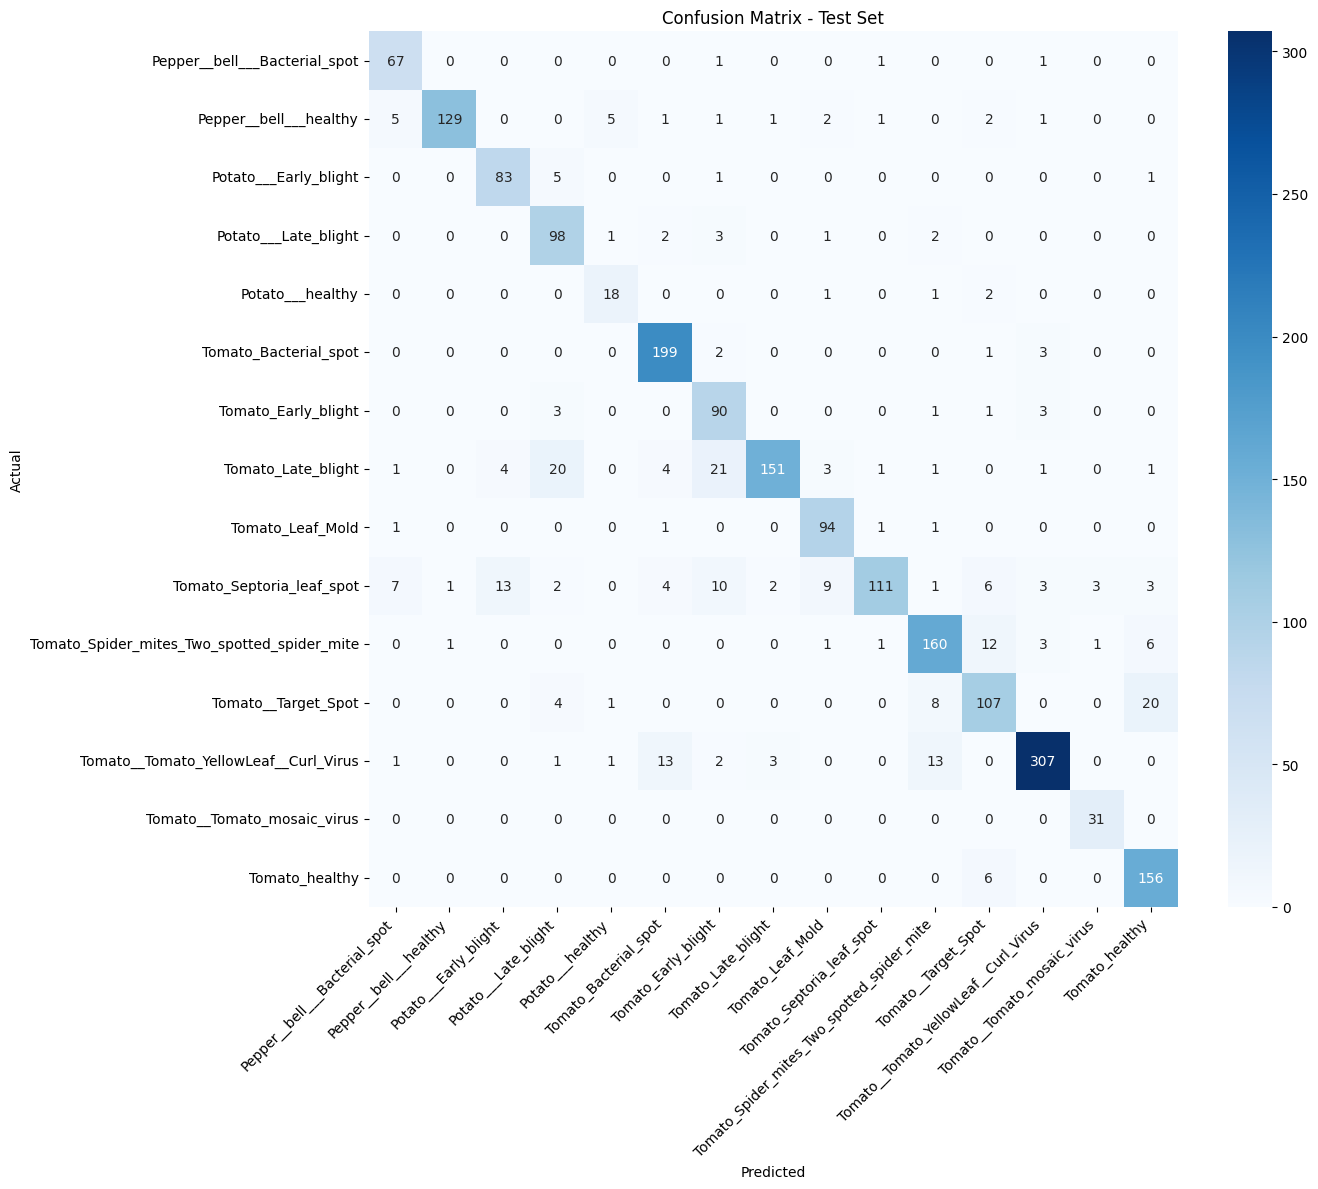

In [32]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Final headline numbers

These are the numbers to report as your project's final results — accuracy on its own, plus macro/weighted precision, recall, and F1 from the classification report above.

In [33]:
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)

print(f"Overall Accuracy:        {report_dict['accuracy']:.4f}")
print(f"Macro-avg Precision:     {report_dict['macro avg']['precision']:.4f}")
print(f"Macro-avg Recall:        {report_dict['macro avg']['recall']:.4f}")
print(f"Macro-avg F1-score:      {report_dict['macro avg']['f1-score']:.4f}")
print(f"Weighted-avg Precision:  {report_dict['weighted avg']['precision']:.4f}")
print(f"Weighted-avg Recall:     {report_dict['weighted avg']['recall']:.4f}")
print(f"Weighted-avg F1-score:   {report_dict['weighted avg']['f1-score']:.4f}")

Overall Accuracy:        0.8659
Macro-avg Precision:     0.8472
Macro-avg Recall:        0.8791
Macro-avg F1-score:      0.8560
Weighted-avg Precision:  0.8780
Weighted-avg Recall:     0.8659
Weighted-avg F1-score:   0.8647


Scores is just a list containing loss and accuracy value

### Plotting the Accuracy and Loss Curves

In [34]:
history

You can read documentation on history object here: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History

In [35]:
history.params

{'verbose': 1, 'epochs': 10, 'steps': 516}

In [36]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

**loss, accuracy, val loss etc are a python list containing values of loss, accuracy etc at the end of each epoch**

In [37]:
type(history.history['loss'])

list

In [38]:
len(history.history['loss'])

10

In [39]:
history.history['loss'][:5] # show loss for first 5 epochs

[2.535562038421631,
 1.7188217639923096,
 1.2110803127288818,
 0.897838294506073,
 0.7849298119544983]

In [40]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

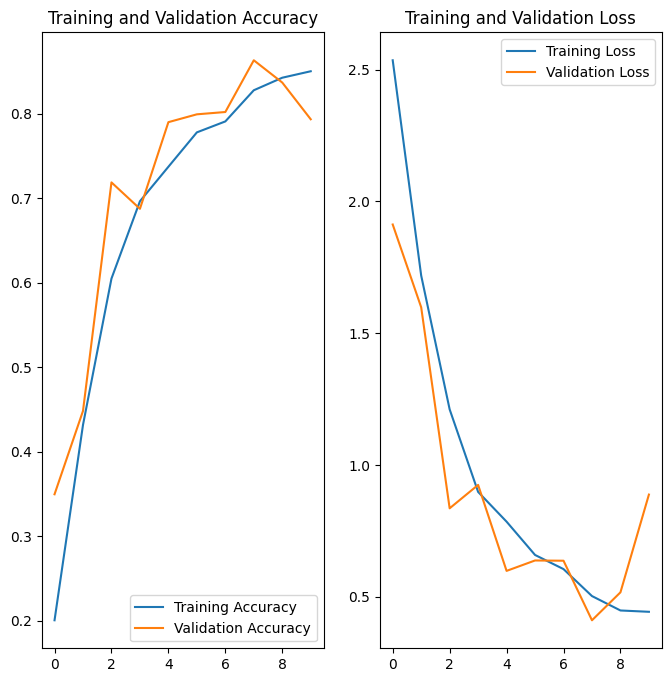

In [41]:
epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Run prediction on a sample image

first image to predict
actual label: Tomato_Septoria_leaf_spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
predicted label: Tomato_Septoria_leaf_spot


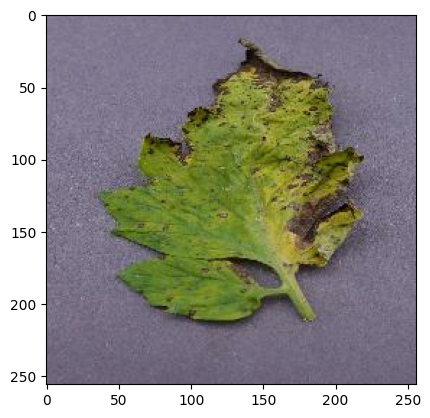

In [42]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

### Write a function for inference

In [43]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

**Now run inference on few sample images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


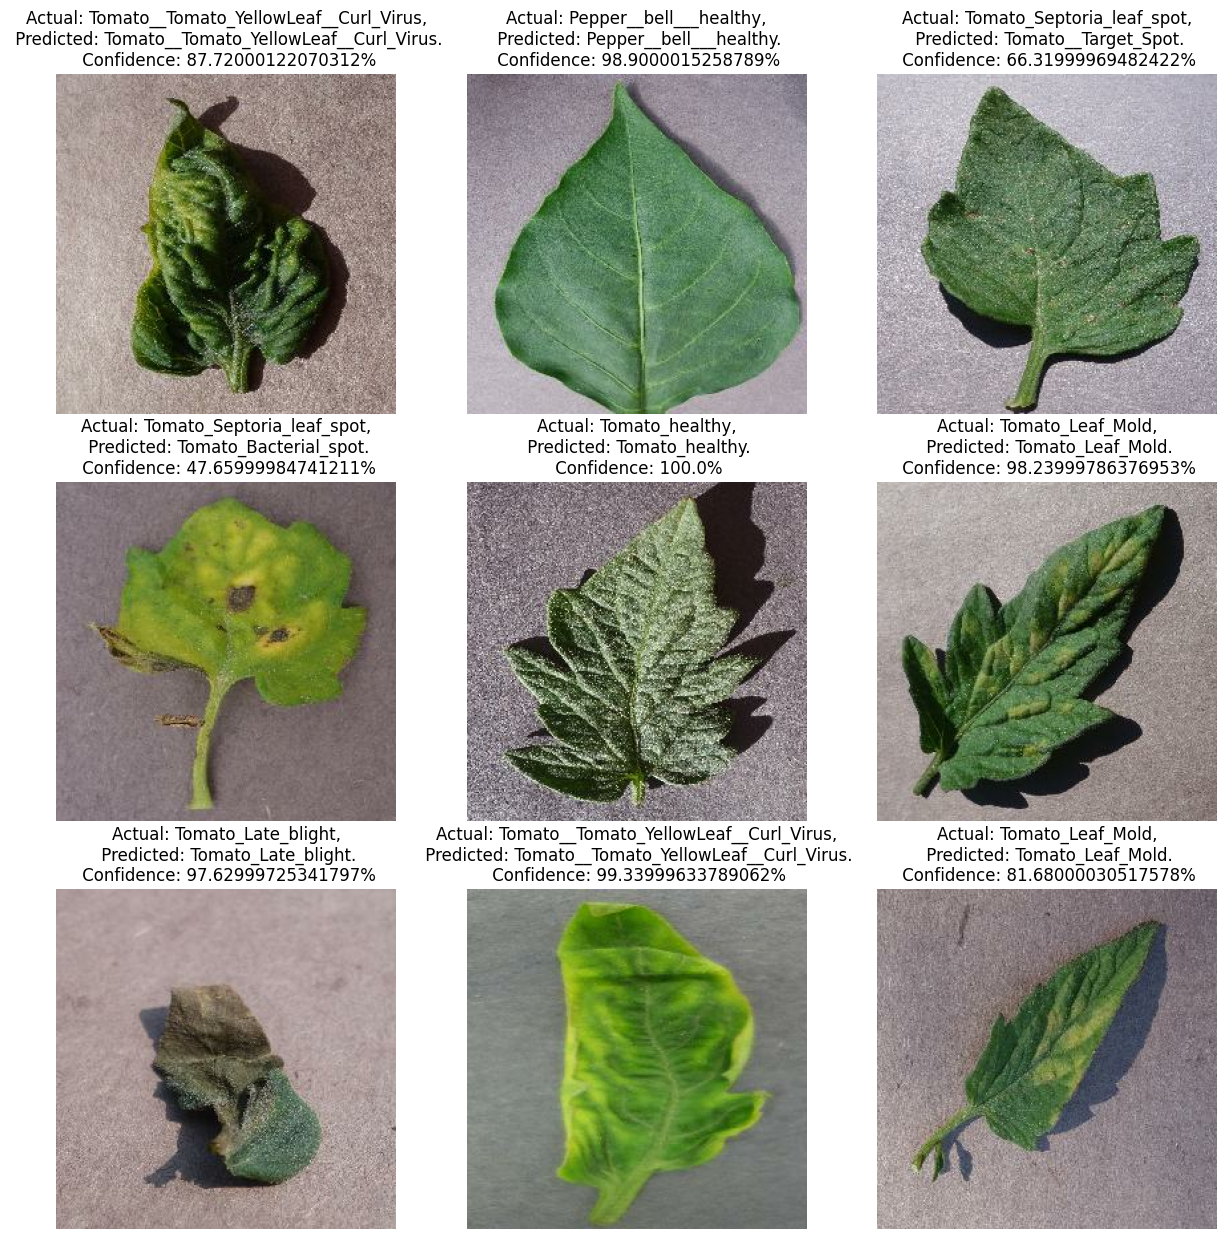

In [44]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

### Saving the Model
We append the model to the list of models as a new version

In [ ]:
model.save("../potatoes.h5")